In [1]:
import torch
print(torch.__version__)

2.14.0+cpu


In [4]:
import numpy as np
import pandas as pd
df = pd.read_csv('train.csv', encoding = 'latin1')
df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [2]:
import torch
import torch.nn as nn

# Quick functional test
x = torch.tensor([1.0, 2.0, 3.0])
print(x)
print(torch.cuda.is_available())  # Will be False on CPU-only install, that's fine

tensor([1., 2., 3.])
False


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
df['Shipping_Delay_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [7]:

model_df = df[['Region', 'Segment', 'Ship Mode', 'Sales', 'Shipping_Delay_Days', 'Category']].dropna()
encoded_df = pd.get_dummies(model_df, columns=['Region', 'Segment', 'Ship Mode'], drop_first=True)

feature_cols = [col for col in encoded_df.columns if col != 'Category']

class StandardScaler:
    def fit_transform(self, data):
        data = np.asarray(data, dtype=float)
        self.mean_ = data.mean(axis=0)
        self.scale_ = data.std(axis=0)
        self.scale_[self.scale_ == 0] = 1
        return (data - self.mean_) / self.scale_

scaler = StandardScaler()
encoded_df[['Sales', 'Shipping_Delay_Days']] = scaler.fit_transform(encoded_df[['Sales', 'Shipping_Delay_Days']])

In [8]:
label_map = {'Furniture': 0, 'Office Supplies': 1, 'Technology': 2}
encoded_df['Category_encoded'] = encoded_df['Category'].map(label_map)

encoded_df[['Category', 'Category_encoded']].head()

,Category,Category_encoded
0,Furniture,0
1,Furniture,0
2,Office Supplies,1
3,Furniture,0
4,Office Supplies,1


In [9]:
np.random.seed(42)
shuffled_indices = np.random.permutation(len(encoded_df))
test_size = int(len(encoded_df) * 0.2)

test_indices = shuffled_indices[:test_size]
train_indices = shuffled_indices[test_size:]

X_train = encoded_df.iloc[train_indices][feature_cols].values.astype(np.float32)
y_train = encoded_df.iloc[train_indices]['Category_encoded'].values.astype(np.int64)
X_test = encoded_df.iloc[test_indices][feature_cols].values.astype(np.float32)
y_test = encoded_df.iloc[test_indices]['Category_encoded'].values.astype(np.int64)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (7840, 10)
Test shape: (1960, 10)


In [10]:

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test)

In [11]:
class CategoryClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=16, num_classes=3):
        super(CategoryClassifier, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(hidden_size // 2, num_classes)

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.output(x)
        return x

model = CategoryClassifier(input_size=X_train.shape[1])
print(model)

CategoryClassifier(
  (layer1): Linear(in_features=10, out_features=16, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=8, out_features=3, bias=True)
)


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


Epoch [10/100], Loss: 0.8143
Epoch [20/100], Loss: 0.8142
Epoch [30/100], Loss: 0.8141
Epoch [40/100], Loss: 0.8140
Epoch [50/100], Loss: 0.8138
Epoch [60/100], Loss: 0.8137
Epoch [70/100], Loss: 0.8136
Epoch [80/100], Loss: 0.8135
Epoch [90/100], Loss: 0.8134
Epoch [100/100], Loss: 0.8132


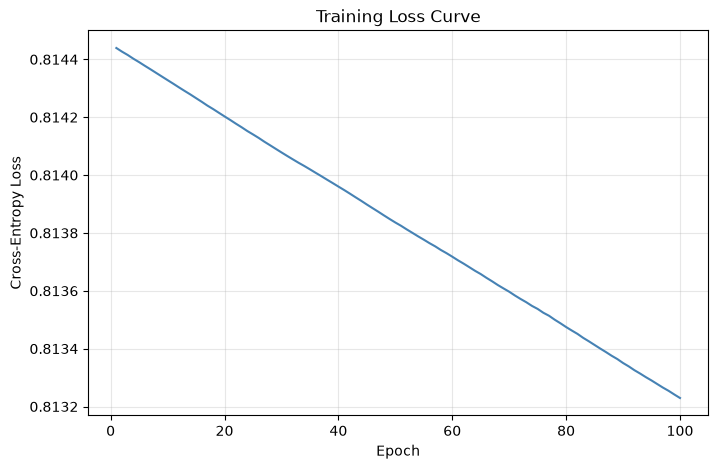

Test Accuracy after extended training: 0.6245


In [18]:
num_epochs = 100
train_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, color='steelblue')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(alpha=0.3)
plt.show()
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    _, predicted = torch.max(test_outputs, 1)
    accuracy = (predicted == y_test_t).float().mean()
    print(f"Test Accuracy after extended training: {accuracy.item():.4f}")

In [19]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    _, predicted = torch.max(test_outputs, 1)

y_pred_nn = predicted.numpy()
y_test_np = y_test_t.numpy()

labels_idx = [0, 1, 2]
labels_names = ['Furniture', 'Office Supplies', 'Technology']

def confusion_matrix_manual(y_true, y_pred, labels):
    matrix = np.zeros((len(labels), len(labels)), dtype=int)
    for actual, pred in zip(y_true, y_pred):
        matrix[actual][pred] += 1
    return matrix

cm_nn = confusion_matrix_manual(y_test_np, y_pred_nn, labels_idx)
cm_df = pd.DataFrame(cm_nn, index=[f"Actual {l}" for l in labels_names], columns=[f"Predicted {l}" for l in labels_names])
print(cm_df)

                        Predicted Furniture  Predicted Office Supplies  \
Actual Furniture                        139                        213   
Actual Office Supplies                  116                       1034   
Actual Technology                       116                        197   

                        Predicted Technology  
Actual Furniture                          53  
Actual Office Supplies                    41  
Actual Technology                         51  


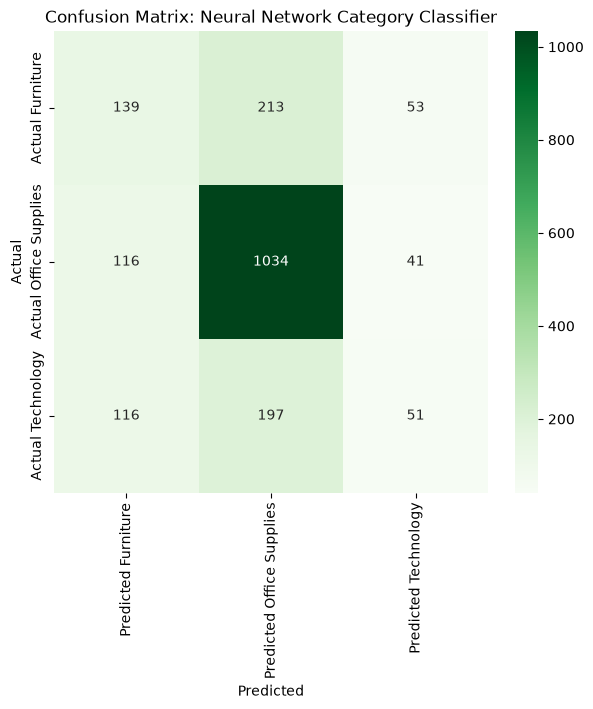

In [20]:
import seaborn as sns

plt.figure(figsize=(7,6))
sns.heatmap(pd.DataFrame([[139,213,53],[116,1034,41],[116,197,51]],
            index=["Actual Furniture","Actual Office Supplies","Actual Technology"],
            columns=["Predicted Furniture","Predicted Office Supplies","Predicted Technology"]),
            annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Neural Network Category Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [21]:
model.eval()
with torch.no_grad():
    train_outputs = model(X_train_t)
    _, train_predicted = torch.max(train_outputs, 1)
    train_accuracy = (train_predicted == y_train_t).float().mean()
    print(f"Train Accuracy: {train_accuracy.item():.4f}")

print(f"Test Accuracy: {accuracy.item():.4f}")
print(f"Gap (Train - Test): {train_accuracy.item() - accuracy.item():.4f}")

Train Accuracy: 0.6338
Test Accuracy: 0.6245
Gap (Train - Test): 0.0093
